# NLP in Detail: Parts of Speech Tagging and Topic Modeling

This notebook will guide you through two fundamental techniques in Natural Language Processing (NLP): **Parts of Speech (POS) Tagging** and **Topic Modeling**.

## 1. Parts of Speech (POS) Tagging

**What is POS Tagging?**

Parts of Speech (POS) Tagging is the process of marking up a word in a text (corpus) as corresponding to a particular part of speech, based on both its definition and its context. For example, in the sentence "The quick brown fox jumps over the lazy dog," 'quick', 'brown', 'lazy' are adjectives, 'fox', 'dog' are nouns, 'jumps' is a verb, and 'over' is a preposition.

**Why is it important?**

POS tagging is a crucial step in many NLP tasks:
*   **Word Sense Disambiguation**: Understanding the correct meaning of a word when it has multiple meanings (e.g., 'bank' as a financial institution vs. 'bank' as a river bank).
*   **Named Entity Recognition (NER)**: Identifying and classifying named entities (like persons, organizations, locations) in text.
*   **Syntactic Parsing**: Understanding the grammatical structure of sentences.
*   **Machine Translation**: Ensuring correct grammar in translated text.
*   **Information Extraction**: Extracting specific data from unstructured text.

We will use the NLTK (Natural Language Toolkit) library for POS tagging, which is a popular choice for academic and research purposes due to its extensive functionalities.

### Installation and Imports

In [ ]:
# Install NLTK (if not already installed)
%pip install nltk

# Import necessary NLTK modules
import nltk
from nltk.tokenize import word_tokenize

# Download the 'punkt' tokenizer and 'averaged_perceptron_tagger' for POS tagging
try:
    nltk.data.find('tokenizers/punkt')
except nltk.downloader.DownloadError:
    nltk.download('punkt')
try:
    nltk.data.find('taggers/averaged_perceptron_tagger')
except nltk.downloader.DownloadError:
    nltk.download('averaged_perceptron_tagger')

### POS Tagging Example

In [ ]:
text = "Natural Language Processing (NLP) is a field of artificial intelligence that focuses on the interaction between computers and human language."

# Tokenize the text into words
words = word_tokenize(text)

# Perform POS tagging
pos_tags = nltk.pos_tag(words)

print("Original Text:", text)
print("\nWords:", words)
print("\nPOS Tags:", pos_tags)

print("\n--- Common NLTK POS Tags ---")
print("NN: Noun, singular or mass (e.g., 'cat')")
print("NNS: Noun, plural (e.g., 'cats')")
print("NNP: Proper noun, singular (e.g., 'John')")
print("VB: Verb, base form (e.g., 'eat')")
print("VBG: Verb, gerund or present participle (e.g., 'eating')")
print("JJ: Adjective (e.g., 'happy')")
print("RB: Adverb (e.g., 'quickly')")
print("IN: Preposition or subordinating conjunction (e.g., 'in')")
print("DT: Determiner (e.g., 'the')")

## 2. Topic Modeling

**What is Topic Modeling?**

Topic modeling is an unsupervised machine learning technique used to discover the hidden semantic structures, or "topics," within a collection of documents. It's a method for finding abstract "topics" that occur in a collection of documents.

Imagine you have thousands of news articles. Manually categorizing them into topics like 'politics', 'sports', 'technology', etc., would be incredibly time-consuming. Topic modeling algorithms can automatically identify these underlying themes.

**How it works (simplified)?**

Topic modeling algorithms, like Latent Dirichlet Allocation (LDA), assume that:
1.  Each document is a mixture of various topics.
2.  Each topic is a mixture of various words.

The algorithm then tries to reverse-engineer this process: given a collection of documents, it identifies the word probabilities for each topic and the topic probabilities for each document.

**Why is it important?**

*   **Document Clustering and Categorization**: Grouping similar documents together.
*   **Information Retrieval**: Improving search results by understanding document themes.
*   **Content Recommendation**: Suggesting articles or products based on user interests.
*   **Summarization**: Identifying key themes in large text corpora.
*   **Exploratory Data Analysis**: Gaining insights into large collections of text data.

We will use `scikit-learn` for its `CountVectorizer` and `LatentDirichletAllocation` implementation, which are standard for this task, and then `gensim` for a more flexible LDA implementation.

### Installation and Imports

In [ ]:
# Install necessary libraries (if not already installed)
%pip install scikit-learn gensim

# Import modules for Topic Modeling
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import numpy as np

### Topic Modeling Example (using LDA)

In [ ]:
# Sample documents
documents = [
    "The quick brown fox jumps over the lazy dog. The dog barks loudly.",
    "Cats love to chase mice. A cat sat on the mat.",
    "Artificial intelligence is transforming the world. Machine learning is a key part of AI.",
    "Deep learning models are revolutionizing data science. Neural networks are complex algorithms.",
    "The cat purred contentedly. The dog wagged its tail happily.",
    "Robots are becoming more common in factories. Automation is increasing productivity."
]

# 1. Text Preprocessing (Tokenization, Lowercasing, Stopword Removal - simplified for demo)
# A more robust solution would involve NLTK or SpaCy for stopword removal and stemming/lemmatization.

# For simplicity, we'll let CountVectorizer handle some of this.

# 2. Create a Document-Term Matrix
# CountVectorizer converts a collection of text documents to a matrix of token counts.
vectorizer = CountVectorizer(stop_words='english', lowercase=True, max_features=1000)
data_vectorized = vectorizer.fit_transform(documents)

# Get feature names (words) for later use
feature_names = vectorizer.get_feature_names_out()

print("Document-Term Matrix Shape:", data_vectorized.shape)
print("\nFirst 5 words in vocabulary:", feature_names[:5])


In [ ]:
# 3. Apply Latent Dirichlet Allocation (LDA)
n_components = 2 # Let's try to find 2 topics
lda_model = LatentDirichletAllocation(
    n_components=n_components,
    random_state=42,
    learning_method='batch',
    n_jobs=-1 # Use all available CPU cores
)

lda_output = lda_model.fit_transform(data_vectorized)

# 4. Display Topics
def display_topics(model, feature_names, no_top_words):
    for topic_idx, topic in enumerate(model.components__):
        print(f"Topic {topic_idx + 1}:")
        print("   " + " ".join([feature_names[i]
                        for i in topic.argsort()[:-no_top_words - 1:-1]]))

no_top_words = 5 # Number of top words to display for each topic
print(f"\nTop {no_top_words} words per topic:\n")
display_topics(lda_model, feature_names, no_top_words)

# 5. Document-Topic Distribution
print("\nDocument-Topic Distribution (each row is a document, columns are topic probabilities):\n")
for i, doc_topic in enumerate(lda_output):
    print(f"Document {i+1}: {np.round(doc_topic, 2)}")


### Interpretation of LDA Results

From the output above:
*   **Topic Words**: You can see that `Topic 1` seems to be related to 'animal' themes (dog, cat, fox, lazy, chase), while `Topic 2` is more about 'technology/AI' (learning, machine, artificial, intelligence, robots).
*   **Document-Topic Distribution**: Each document is assigned a probability score for each topic. For instance, `Document 1` has a higher probability for `Topic 1`, which aligns with its content about 'fox' and 'dog'. `Document 3` has a higher probability for `Topic 2` (AI, machine learning). This shows how the model has successfully identified the underlying themes.

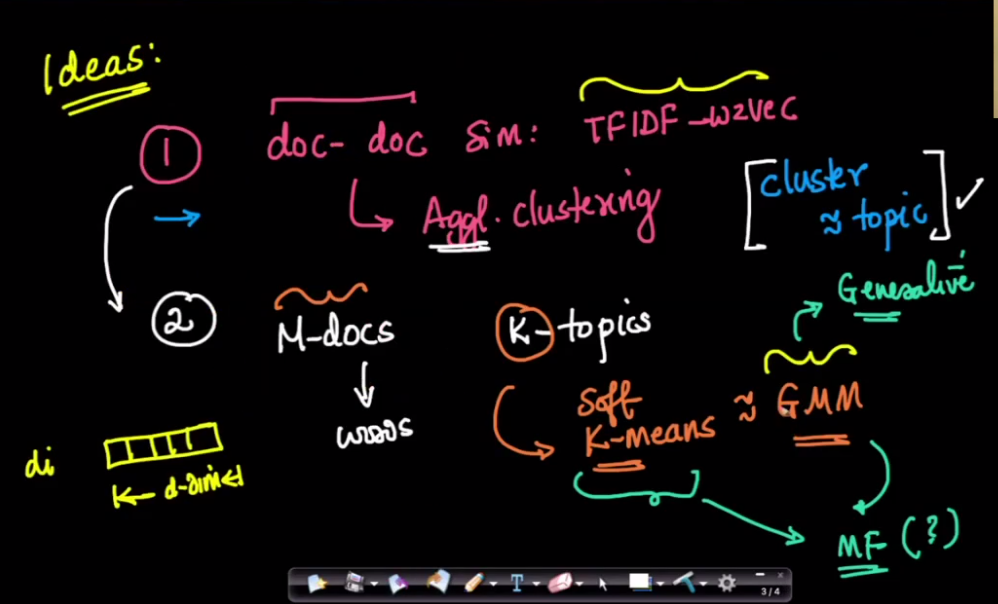

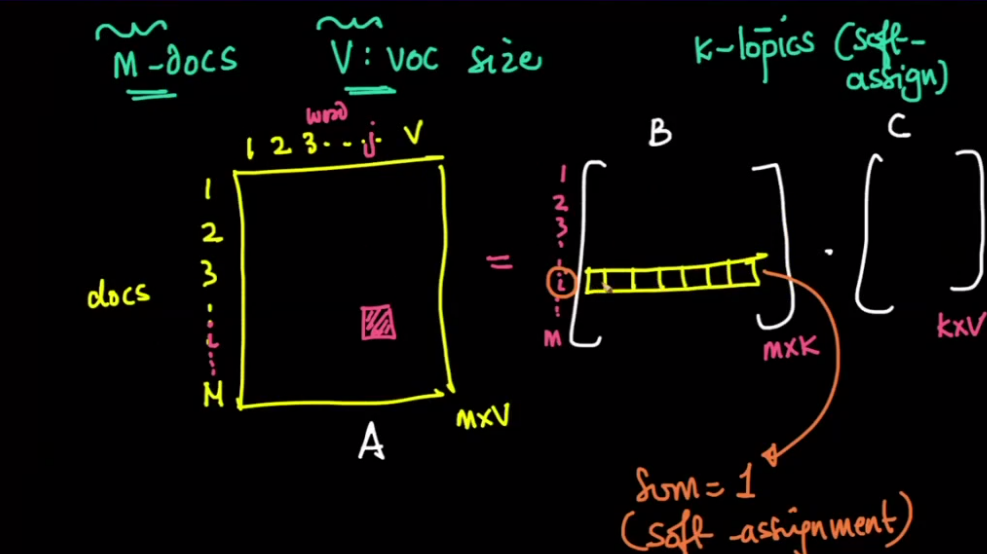